In [1]:
!pip install torch_geometric

In [2]:
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-cluster pyg-lib
!pip install torch==2.5.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.5.1+cpu.html
!pip install --upgrade torch-geometric

Found existing installation: torch 2.5.1+cpu
Uninstalling torch-2.5.1+cpu:
  Successfully uninstalled torch-2.5.1+cpu
Found existing installation: torchvision 0.20.1+cpu
Uninstalling torchvision-0.20.1+cpu:
  Successfully uninstalled torchvision-0.20.1+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
Found existing installation: torch_scatter 2.1.2+pt25cpu
Uninstalling torch_scatter-2.1.2+pt25cpu:
  Successfully uninstalled torch_scatter-2.1.2+pt25cpu
Found existing installation: torch_sparse 0.6.18+pt25cpu
Uninstalling torch_sparse-0.6.18+pt25cpu:
  Successfully uninstalled torch_sparse-0.6.18+pt25cpu
Found existing installation: torch_cluster 1.6.3+pt25cpu
Uninstalling torch_cluster-1.6.3+pt25cpu:
  Successfully uninstalled torch_cluster-1.6.3+pt25cpu
Found existing installation: pyg_lib 0.4.0+pt25cpu
Uninstalling pyg_lib-0.4.0+pt25cpu:
  Successfully uninstalled pyg_lib-0.4.0+pt25cpu
Looking i

In [3]:
!pip install pyg-lib -f https://data.pyg.org/whl/torch-2.6.0+cpu.html

Looking in links: https://data.pyg.org/whl/torch-2.6.0+cpu.html


In [4]:
import torch
from sklearn.metrics import roc_auc_score
import torch_geometric as tg
from torch_geometric.data import Data
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from torch_geometric.transforms import RandomLinkSplit
import torch.nn as nn
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
from LinkPredictor import LinkPredictor, LinkPredictionMessagePassingModel
import numpy as np
from torch_geometric.loader import LinkNeighborLoader


In [5]:
!python etc_graph_builder.py token_transfers_last_6600_blocks.csv

Загружено 84610 транзакций
Граф NetworkX: 34784 вершин, 43945 рёбер
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/storage.py:863: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  num_nodes, num_edges = self.num_nodes, self.num_edges
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/storage.py:780: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  size = (self.num_nodes, self.num_nodes)
/usr/local/lib/python3.12/dist-packages/torch_geometric/data/data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_attr', 'edge_label_index', 'edge_label', 'edge_index'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning

In [6]:
def load_link_pred_data(path):
    checkpoint = torch.load(path, weights_only=False)
    train_data = checkpoint['train_data']
    val_data = checkpoint['val_data']
    test_data = checkpoint['test_data']
    num_neighbors = checkpoint['num_neighbors']
    batch_size = checkpoint['batch_size']

    train_loader = LinkNeighborLoader(
        train_data,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        edge_label_index=train_data.edge_label_index,
        edge_label=train_data.edge_label,
        shuffle=True,
    )
    val_loader = LinkNeighborLoader(
        train_data,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        edge_label_index=val_data.edge_label_index,
        edge_label=val_data.edge_label,
        shuffle=False,
    )
    test_loader = LinkNeighborLoader(
        train_data,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        edge_label_index=test_data.edge_label_index,
        edge_label=test_data.edge_label,
        shuffle=False,
    )

    return train_data, val_data, test_data, train_loader, val_loader, test_loader
train_data, val_data, test_data, train_loader, val_loader, test_loader = load_link_pred_data('ethereum_link_pred_data.pt')

In [7]:
train_data.is_undirected()

False

In [8]:
train_data.has_isolated_nodes()

True

In [9]:
train_data.has_self_loops()

False

In [10]:
num_edges_to_draw = 5000
edges = train_data.edge_index[:, :num_edges_to_draw]

unique_nodes, relabeled = torch.unique(edges, return_inverse=True)
relabeled = relabeled.view(2, -1)

sub_data = Data(edge_index=relabeled, num_nodes=len(unique_nodes))

G = to_networkx(sub_data, to_undirected=True)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.3, seed=42, iterations=50)
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='skyblue', alpha=0.7)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.5)
plt.axis('off')
plt.title(f'Фрагмент графа ({num_edges_to_draw} рёбер, {len(unique_nodes)} уникальных узлов)')
plt.savefig('graph_sample.png', dpi=300, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

<Figure size 1400x1000 with 0 Axes>

Тип: Ориентированный, Узлов: 34783, Рёбер: 35142
Плотность: 0.00003
Ср. вх. степень: 1.01, макс. вх.: 1526
Ср. исх. степень: 1.01, макс. исх.: 1977
Компонент слабой связности: 6386, размер макс. компоненты: 24192
Диаметр не вычислить (граф не связен или пуст)


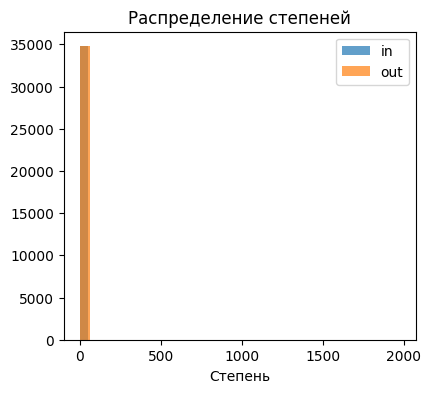

In [27]:
def explore_graph(G, max_nodes_visualize=100):
    """
    Быстрый разведочный анализ графа: базовые метрики, степени, связность, диаметр,
    кластеризация, визуализация.
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    is_directed = G.is_directed()

    print("=" * 50)
    print(f"Тип: {'Ориентированный' if is_directed else 'Неориентированный'}, "
          f"Узлов: {n}, Рёбер: {m}")
    if n > 0:
        denom = n * (n - 1)
        density = (m / denom) if is_directed else (2 * m / denom)
        print(f"Плотность: {density:.5f}")

    # Степени
    if is_directed:
        in_deg = dict(G.in_degree())
        out_deg = dict(G.out_degree())
        print(f"Ср. вх. степень: {np.mean(list(in_deg.values())):.2f}, "
              f"макс. вх.: {max(in_deg.values())}")
        print(f"Ср. исх. степень: {np.mean(list(out_deg.values())):.2f}, "
              f"макс. исх.: {max(out_deg.values())}")
        deg_seq = list(dict(G.degree()).values())
    else:
        deg = dict(G.degree())
        deg_seq = list(deg.values())
        print(f"Ср. степень: {np.mean(deg_seq):.2f}, "
              f"макс: {max(deg_seq)}, мин: {min(deg_seq)}")
        isolated = sum(1 for d in deg_seq if d == 0)
        print(f"Изолированных узлов: {isolated}")

    # Гистограмма степеней
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    if is_directed:
        plt.hist(list(in_deg.values()), bins=30, alpha=0.7, label='in')
        plt.hist(list(out_deg.values()), bins=30, alpha=0.7, label='out')
        plt.legend()
    else:
        plt.hist(deg_seq, bins=30, alpha=0.7)
    plt.xlabel('Степень')
    plt.title('Распределение степеней')

    # Компоненты связности и диаметр
    if is_directed:
        largest_cc = max(nx.weakly_connected_components(G), key=len)
        n_weak = sum(1 for _ in nx.weakly_connected_components(G))
        print(f"Компонент слабой связности: {n_weak}, "
              f"размер макс. компоненты: {len(largest_cc)}")
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        n_cc = sum(1 for _ in nx.connected_components(G))
        print(f"Компонент связности: {n_cc}, "
              f"размер макс. компоненты: {len(largest_cc)}")

    G_largest = G.subgraph(largest_cc).copy()
    if len(largest_cc) > 1:
        try:
            diam = nx.diameter(G_largest)
            avg_path = nx.average_shortest_path_length(G_largest)
            print(f"Диаметр (в макс. комп.): {diam}, ср. длина пути: {avg_path:.2f}")
        except nx.NetworkXError:
            print("Диаметр не вычислить (граф не связен или пуст)")

    if not is_directed:
        clust = nx.average_clustering(G)
        print(f"Средний кластерный коэфф.: {clust:.4f}")


    print("=" * 50)

G_all = to_networkx(train_data)
explore_graph(G_all)